# U–Th Radiometric Age Dating
**Pipeline v2** — sequential Monte Carlo — single-sample or batch CSV

Run cells top-to-bottom. Edit only the **Configuration** cell to adapt to your data.

In [62]:
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns
import hickle as hkl
from tqdm.notebook import tqdm

# Local modules — notebook must be opened from the UTh_project directory
from pipeline import load_csv
from workers import workers, Measurement
from isotope_constants import (
    lambda_234, lambda_238, lambda_230, lambda_232,
    MAX_AGE, Th230_Th232_ini,
)
from age_calc_Th230_U238_CS import age_calc_Th230_U238_CS
from m_Th230_U238_a_from_concs import m_Th230_U238_a_from_concs
from calc_Th230_U238_act import calc_Th230_U238_act

---
## Configuration
Edit **only this cell** before running the rest of the notebook.

In [63]:
# ── Input ──────────────────────────────────────────────────────────────────────
INPUT_MODE = "csv"           # "csv"  → load from file  |  "manual" → use dict below
#CSV_PATH   = "Prueba_repro_ U-Th dating.csv"
CSV_PATH   = "31032025 U-Th dating.csv"

# Manual single-sample input (ignored when INPUT_MODE = "csv")
SAMPLE = {
    "Sample":       "MY_SAMPLE",
    "U238_ppb":     500.0,    "U238_rsd":        0.01,
    "Th230_pmolg":  0.015,    "Th230_pmolg_err": 0.0003,
    "Th232_pmol":   0.002,    "Th232_err":       0.0001,
    "delta_234U":   85.0,     "delta_234U_err":  1.5,
}

# ── Monte Carlo ─────────────────────────────────────────────────────────────────
N_WALKS = 10000   # use 100 for quick test; 10_000 for final results

# ── Output ──────────────────────────────────────────────────────────────────────
OUTPUT_STEM = "results2"   # base name  →  results.csv  /  .xlsx  /  .pdf
SAVE_CSV    = True
SAVE_EXCEL  = True
SAVE_PDF    = True

# ── Report annotations ────────────────────────────────────────────────────────
REPORT_NOTE = " Sample text lorem ipsum"   # optional free-text note shown on the title page directly
                   # below the metadata table, e.g.:
                   # "Project: CAVE01 · Funding: ERC-2024 · PI approval pending"


---
## Step 1 — Load measurement data

In [64]:
if INPUT_MODE == "csv":
    data = load_csv(CSV_PATH)
    print(f"Loaded {len(data)} sample(s) from '{CSV_PATH}'")
else:
    data = pd.DataFrame([SAMPLE])
    print(f"Manual input: sample '{SAMPLE['Sample']}'")

display(data[["Sample", "U238_ppb", "U238_rsd",
              "Th230_pmolg", "Th230_pmolg_err",
              "Th232_pmol", "Th232_err",
              "delta_234U", "delta_234U_err"]])

Loaded 5 sample(s) from '31032025 U-Th dating.csv'


,Sample,U238_ppb,U238_rsd,Th230_pmolg,Th230_pmolg_err,Th232_pmol,Th232_err,delta_234U,delta_234U_err
0,QUA 8 bottom,427.286912,0.001124,0.000700,0.000003,0.031661,0.077890,123.169092,0.472746
1,QUA SIR bottom,542.328863,0.001566,0.001384,0.000006,0.040289,1.800564,284.940944,0.577108
2,CAM 7 top0.4,7717.866602,0.002371,0.365400,0.001009,0.330602,0.163208,111.786440,1.458678
3,CAM 8 34.4,297.766399,0.001136,0.026365,0.000066,0.197665,0.073373,501.039995,0.700397
4,CAM 7 top0.4 rep,7148.255402,0.002775,0.346099,0.001035,0.273545,0.298251,113.281327,1.464755


---
## Step 2 — Monte Carlo age dating

Each walk independently randomises all four measured quantities, applies the detrital
²³⁰Th correction (10 iterations), and solves the ²³⁰Th ingrowth equation.
Results are the mean ± 2σ over all successful walks.

In [65]:
def _run_mc(row, n_walks=N_WALKS):
    '''Run n_walks sequential MC iterations for one sample row.

    Returns (age_uncorr, err_uncorr, age_corr, err_corr, dist, dist_uncorr) where
    ages and errors are integers in years and dist* are lists of valid ages.
    Returns (None, None, None, None, [], []) if the corrected solver never converges.
    '''
    ini_act = m_Th230_U238_a_from_concs(row["Th230_pmolg"], row["U238_ppb"])
    T_est   = age_calc_Th230_U238_CS(0, ini_act, row["delta_234U"])
    if T_est is None:
        T_est = MAX_AGE // 2

    u238  = Measurement(row["U238_ppb"],     row["U238_rsd"],        "rsd")
    th230 = Measurement(row["Th230_pmolg"],  row["Th230_pmolg_err"], "absolute")
    th232 = Measurement(row["Th232_pmol"],   row["Th232_err"],       "absolute")
    d234u = Measurement(row["delta_234U"],   row["delta_234U_err"],  "absolute")

    raw     = [workers(u238, th230, th232, d234u, T_est) for _ in range(n_walks)]
    valid_u = [u for u, c in raw if c is not None]
    valid_c = [c for u, c in raw if c is not None]
    if not valid_c:
        return None, None, None, None, [], []
    return (
        int(np.mean(valid_u)), int(2 * np.std(valid_u)),
        int(np.mean(valid_c)), int(2 * np.std(valid_c)),
        valid_c, valid_u,
    )


records = []
for _, row in tqdm(data.iterrows(), total=len(data), desc="Monte Carlo", unit="sample"):
    age_u, err_u, age_c, err_c, dist, dist_uncorr = _run_mc(row)
    records.append({
        "Sample":      row["Sample"],
        "age_uncorr":  age_u, "err_uncorr":  err_u,
        "age_corr":    age_c, "err_corr":    err_c,
        "dist":        dist,
        "dist_uncorr": dist_uncorr,
    })

results = pd.DataFrame(records)
display(results[["Sample", "age_uncorr", "err_uncorr", "age_corr", "err_corr"]])


Monte Carlo:   0%|          | 0/5 [00:00<?, ?sample/s]

,Sample,age_uncorr,err_uncorr,age_corr,err_corr
0,QUA 8 bottom,2260,20,2259,20
1,QUA SIR bottom,3087,26,3087,46
2,CAM 7 top0.4,97663,1223,97663,1224
3,CAM 8 34.4,164030,1871,164029,1873
4,CAM 7 top0.4 rep,100990,1425,100990,1425


---
## Step 3 — Load pre-computed isoline grids

The three `.hkl` files store the full gridded parameter space (~960 MB each).
Load once per session — skip re-running this cell if the variables are already in memory.

In [66]:
iso_path   = Path(".")
res_final  = hkl.load(iso_path / "Th230_U238_act_isolines.hkl")
delt_final = hkl.load(iso_path / "d234U_measured_isolines.hkl")
age_iso    = np.array(hkl.load(iso_path / "age_isolines.hkl"))   # cast to ndarray for contour()

Th230U238_A = np.arange(0, 2.5, 0.05)
delta234U_m = np.arange(0, 4000, 5)
X, Y = np.meshgrid(Th230U238_A, delta234U_m)

# Upsample grid 4× (X) and 2× (Y) for smoother contour lines.
# Avoids regenerating the large HKL files — interpolation is acceptable for display.
from scipy.ndimage import zoom as _zoom
_ZX, _ZY         = 4, 2
age_iso_fine     = _zoom(age_iso, (_ZY, _ZX))
Th230U238_A_fine = np.linspace(Th230U238_A[0], Th230U238_A[-1], age_iso_fine.shape[1])
delta234U_m_fine = np.linspace(delta234U_m[0],  delta234U_m[-1], age_iso_fine.shape[0])
X_fine, Y_fine   = np.meshgrid(Th230U238_A_fine, delta234U_m_fine)

# Age levels for green isochron lines: dense at young ages, coarser beyond 130 ka
_age_levels = (
    list(range(  5_000, 130_000,  5_000))
  + list(range(130_000, 250_000, 10_000))
  + list(range(250_000, 550_000, 50_000))
)

print(f"Grids loaded.  age_iso shape: {age_iso.shape}  →  upsampled: {age_iso_fine.shape}")


Grids loaded.  age_iso shape: (800, 50)  →  upsampled: (1600, 200)


---
## Step 4 — Diagnostic plots

One 3-panel figure per sample:

| Panel | Content |
|-------|---------|
| **A** (top-left)  | MC age distribution — KDE with mean ± 2σ lines |
| **B** (top-right) | ²³⁰Th/²³⁸U ingrowth curves for δ²³⁴U = 0 and measured δ²³⁴U |
| **C** (bottom)    | Isochron diagram — age isolines, back-evolution path, sample point |

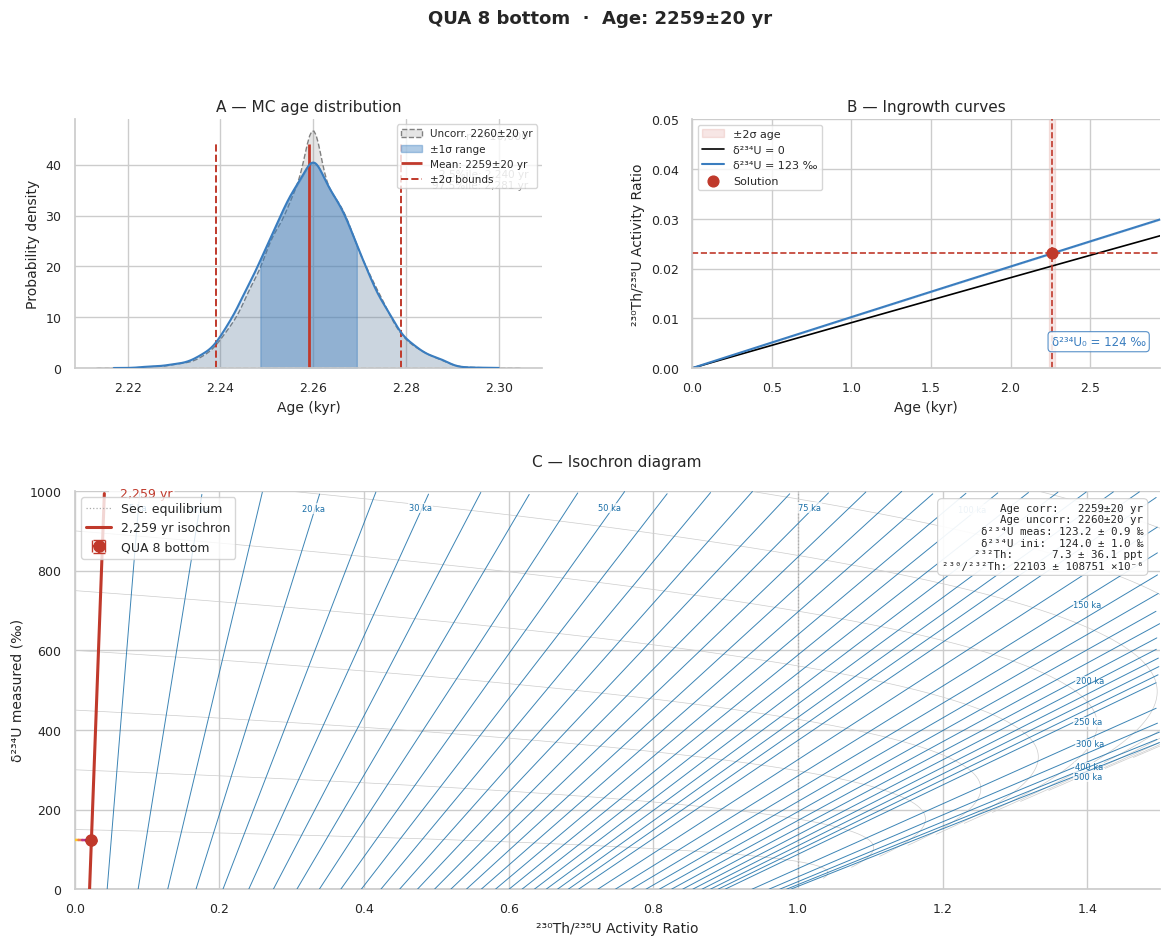

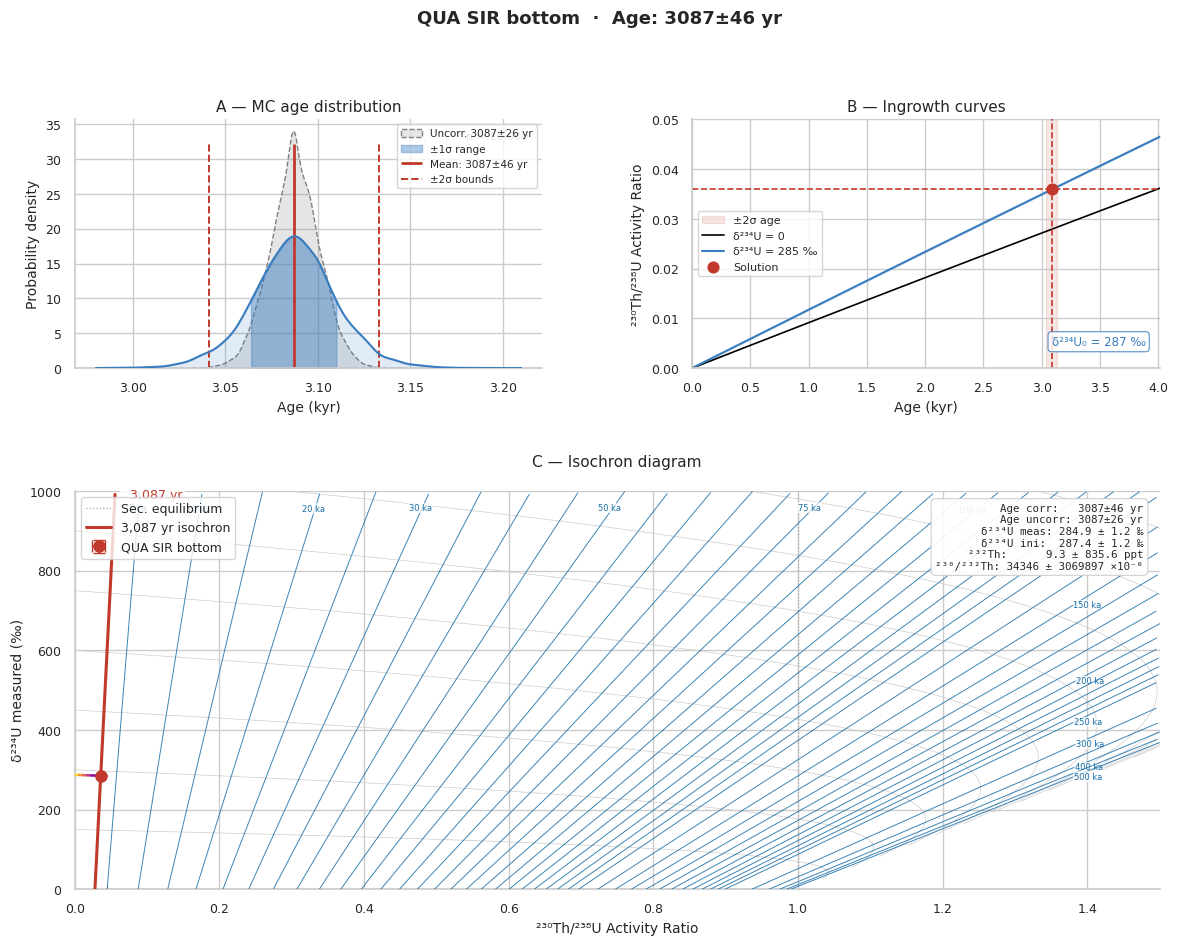

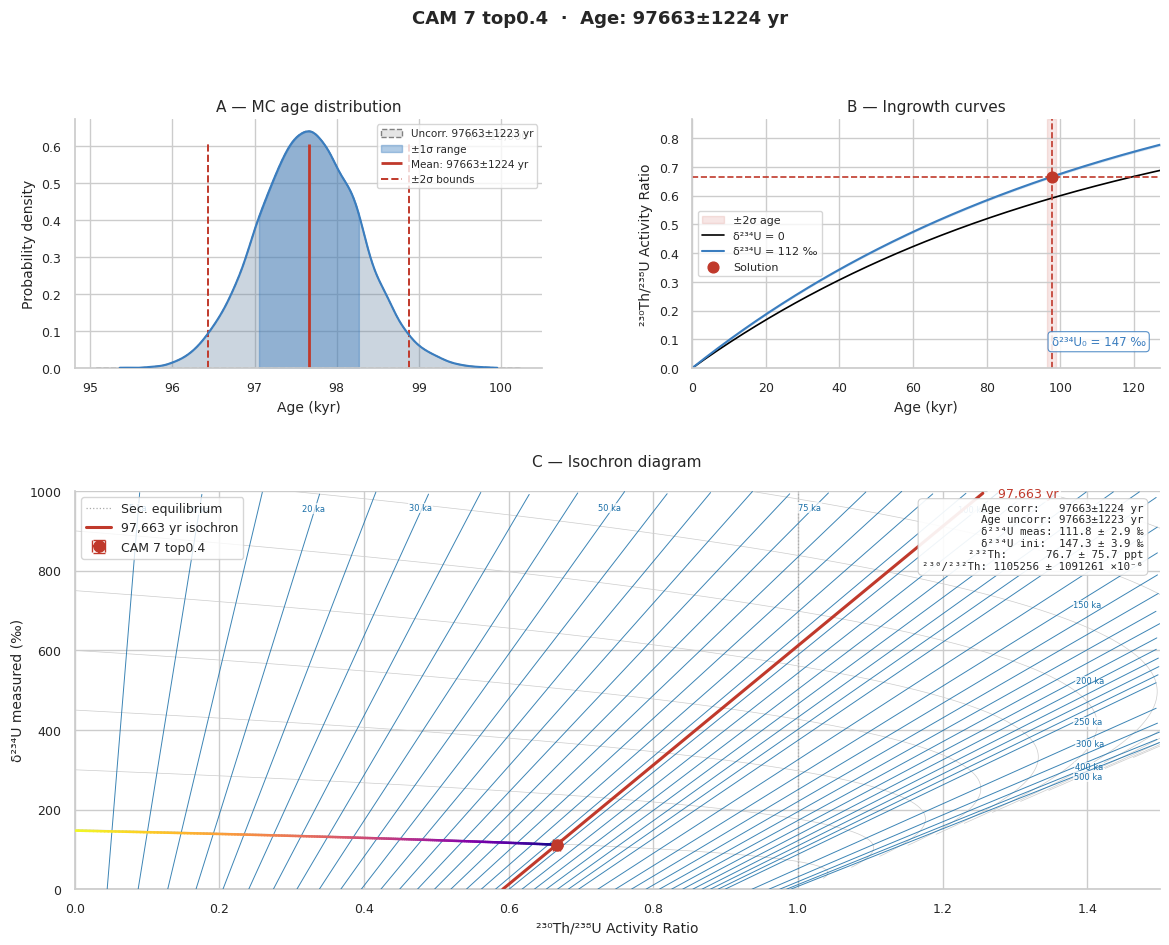

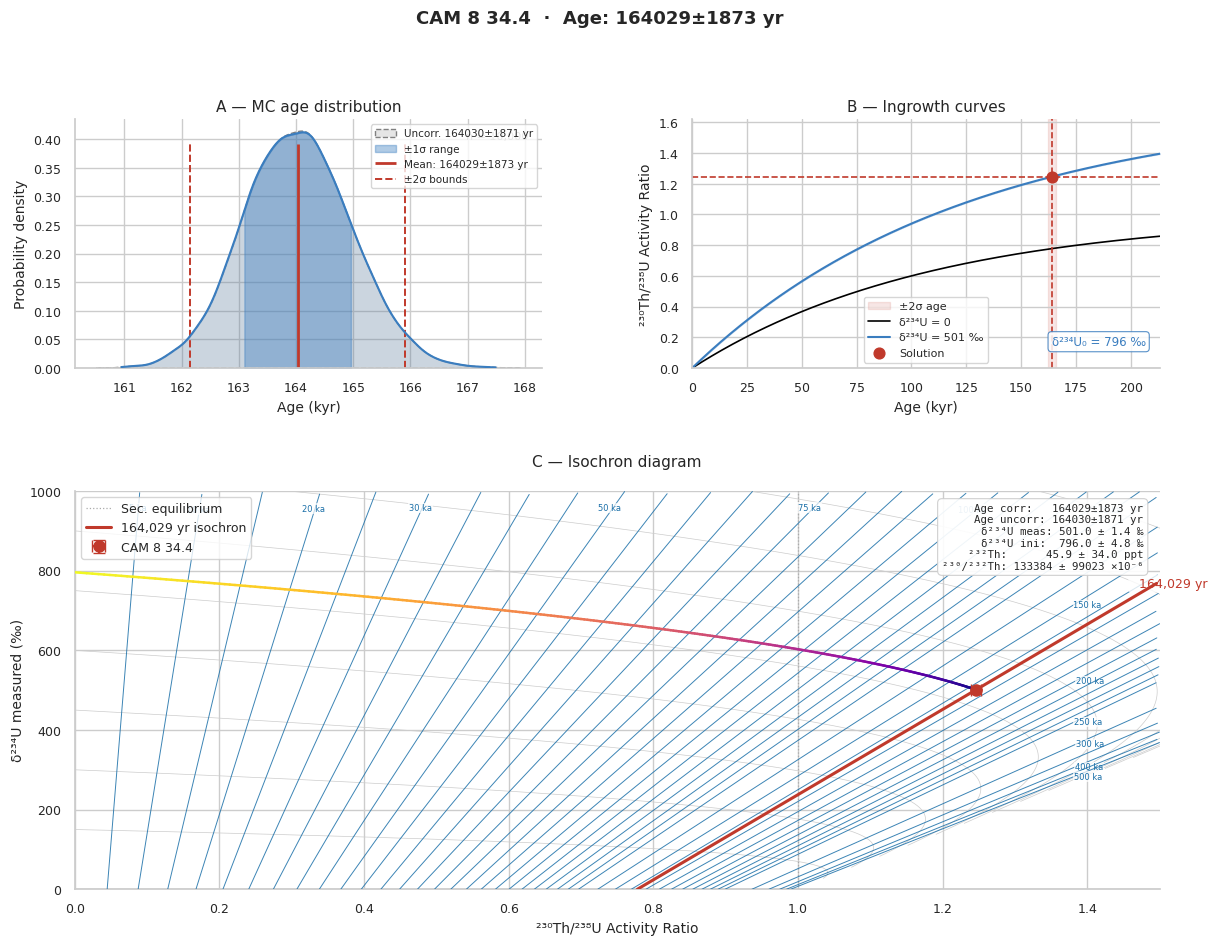

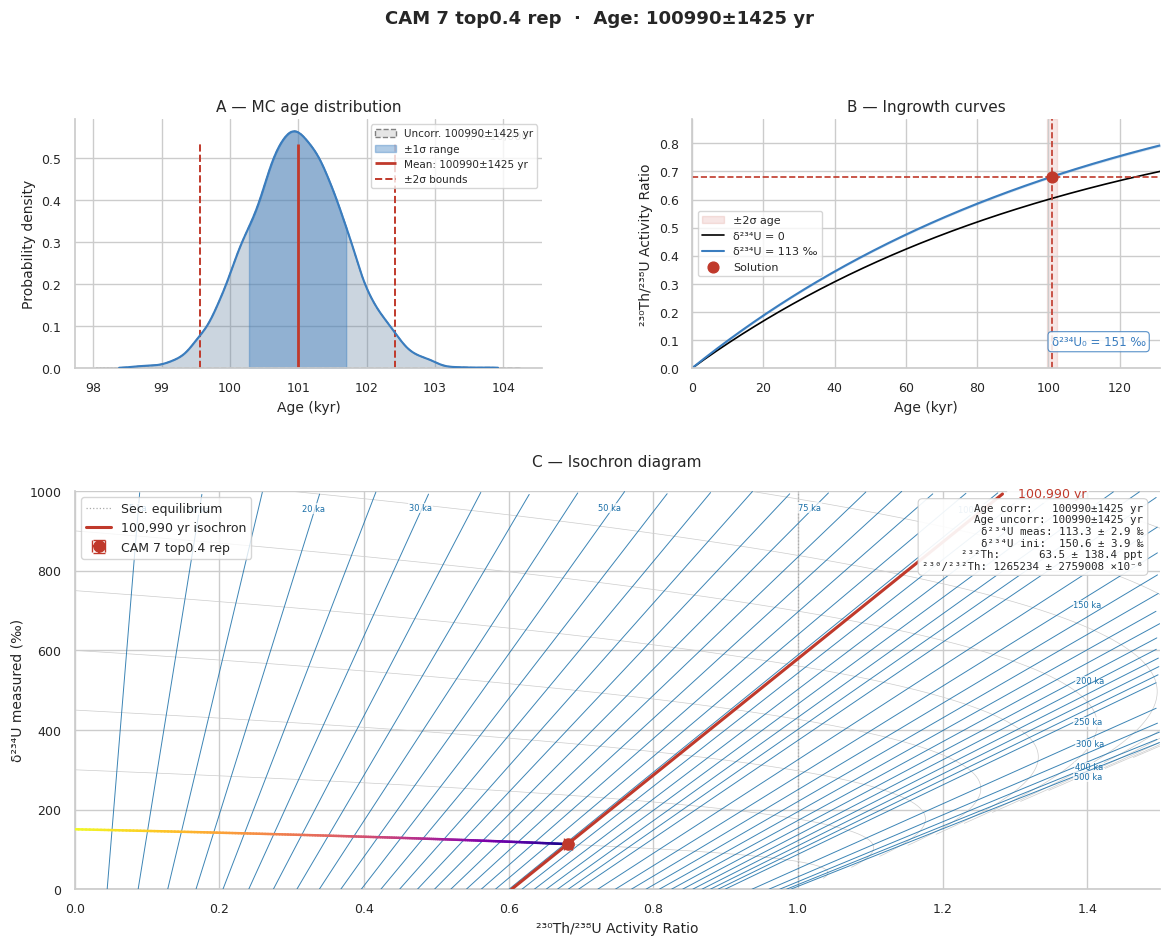

In [67]:
# ── Global plot style ──────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "axes.titlesize":  11,
    "axes.labelsize":  10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})
_EVOL_STEP = 500   # time step (yr) for evolution curves

from scipy.stats import gaussian_kde as _gkde
from matplotlib.colors import Normalize as _Norm
import math as _math


def _fmt(val, err):
    """Auto-precision 'value±error' string matching the results table format.

    Decimal places are chosen so the error shows at least one significant digit.
    Returns '—' for None/invalid inputs.
    """
    if val is None or err is None:
        return "—"
    try:
        mag = _math.floor(_math.log10(abs(err))) if err != 0 else 0
        d   = max(0, 1 - mag) if abs(err) >= 1 else max(0, -mag)
        f   = f"{{:.{d}f}}"
        return f"{f.format(float(val))}±{f.format(float(err))}"
    except Exception:
        return "—"


def _back_evolution(delta_meas, age_yr, step=_EVOL_STEP):
    """Vectorised back-evolution path in the isochron diagram.

    Returns (activity_ratio_array, delta234U_array, time_array) tracing the
    ingrowth curve from the initial state (t=0) to the sample point (t=age_yr).
    """
    times = np.arange(0, age_yr + step, step)
    d_ini = delta_meas * np.exp(lambda_234 * age_yr)
    d_t   = d_ini * np.exp(-lambda_234 * times)
    acts  = calc_Th230_U238_act(d_t, times)
    return acts, d_t, times


def plot_sample(data_row, age_yr, err_2s, dist, age_uncorr, err_uncorr, dist_uncorr):
    """Three-panel diagnostic figure for one sample.

    Parameters
    ----------
    data_row    : pandas Series with measurement columns from pipeline.load_csv()
    age_yr      : mean corrected age in years (int), or None if solver exceeded MAX_AGE
    err_2s      : 2-sigma uncertainty in years (int)
    dist        : list of individual MC corrected ages (yr)
    age_uncorr  : mean uncorrected age in years (int)
    err_uncorr  : 2-sigma uncertainty of uncorrected age (int)
    dist_uncorr : list of individual MC uncorrected ages (yr)

    Returns matplotlib Figure, or None if age_yr is None.
    """
    if age_yr is None:
        print(f"  {data_row['Sample']}: solver exceeded MAX_AGE — skipping plot.")
        return None

    name        = data_row["Sample"]
    ini_act     = m_Th230_U238_a_from_concs(data_row["Th230_pmolg"], data_row["U238_ppb"])
    ini_act_err = ini_act * np.sqrt(
        (data_row["Th230_pmolg_err"] / data_row["Th230_pmolg"]) ** 2
        + data_row["U238_rsd"] ** 2
    )
    delta_meas  = data_row["delta_234U"]
    delta_err   = data_row["delta_234U_err"]

    # δ²³⁴U_initial (back-calculated to t = 0)
    d_ini_val   = delta_meas * np.exp(lambda_234 * age_yr)

    # Reliability flag
    act_230_232 = float(data_row["Th230_pmolg"] * lambda_230
                        / (data_row["Th232_pmol"] * lambda_232))
    flag_sym    = " ⚠" if act_230_232 < 20 else ""

    fig = plt.figure(figsize=(14, 10))
    gs  = gridspec.GridSpec(2, 2, figure=fig,
                            height_ratios=[1, 1.6], hspace=0.38, wspace=0.32)
    ax_A = fig.add_subplot(gs[0, 0])
    ax_B = fig.add_subplot(gs[0, 1])
    ax_C = fig.add_subplot(gs[1, :])

    fig.suptitle(
        f"{name}{flag_sym}  ·  Age: {_fmt(age_yr, err_2s)} yr",
        fontsize=13, fontweight="bold", y=0.99,
    )

    # ── Panel A: MC age distribution ────────────────────────────────────────────
    dist_kyr    = np.array(dist) / 1000
    mean_kyr    = age_yr / 1000
    sigma_1_kyr = np.std(dist_kyr)

    # Uncorrected age KDE in gray (behind corrected)
    if dist_uncorr:
        sns.kdeplot(np.array(dist_uncorr) / 1000, fill=True, color="gray",
                    alpha=0.20, linewidth=1.0, linestyle="--", ax=ax_A,
                    label=f"Uncorr. {_fmt(age_uncorr, err_uncorr)} yr")

    # Corrected KDE with manual ±1σ shaded band
    x_dense  = np.linspace(dist_kyr.min(), dist_kyr.max(), 500)
    kde_vals = _gkde(dist_kyr)(x_dense)
    ax_A.fill_between(x_dense, kde_vals, alpha=0.15, color="#3A7DBF", zorder=1)
    mask_1s  = (x_dense >= mean_kyr - sigma_1_kyr) & (x_dense <= mean_kyr + sigma_1_kyr)
    ax_A.fill_between(x_dense[mask_1s], kde_vals[mask_1s], alpha=0.40,
                      color="#3A7DBF", zorder=2, label="±1σ range")
    ax_A.plot(x_dense, kde_vals, color="#3A7DBF", lw=1.5, zorder=3)

    ymax = ax_A.get_ylim()[1]
    ax_A.vlines(mean_kyr, 0, ymax * 0.9, colors="#C0392B", lw=2.0,
                label=f"Mean: {_fmt(age_yr, err_2s)} yr")
    ax_A.vlines([(age_yr - err_2s) / 1000, (age_yr + err_2s) / 1000],
                0, ymax * 0.9, colors="#C0392B", lw=1.4, linestyles="dashed",
                label="±2σ bounds")

    # Asymmetric percentile annotation when distribution is noticeably skewed
    p025 = np.percentile(dist_kyr, 2.5)
    p975 = np.percentile(dist_kyr, 97.5)
    skew = abs((p975 - mean_kyr) - (mean_kyr - p025)) / (sigma_1_kyr + 1e-12)
    if skew > 0.15:
        ax_A.text(0.97, 0.80,
                  f"2.5%ile: {int(p025 * 1000):,} yr\n97.5%ile: {int(p975 * 1000):,} yr",
                  transform=ax_A.transAxes, ha="right", va="top",
                  fontsize=7.5, color="#888888")

    ax_A.set_xlabel("Age (kyr)")
    ax_A.set_ylabel("Probability density")
    ax_A.set_title("A — MC age distribution")
    ax_A.legend(fontsize=7.5)
    ax_A.text(0.97, 0.95, f"n = {len(dist):,}",
              transform=ax_A.transAxes, ha="right", va="top",
              fontsize=8, color="gray")
    sns.despine(ax=ax_A, top=True, right=True)

    # ── Panel B: ingrowth curves ─────────────────────────────────────────────────
    t_rng   = np.arange(0, min(age_yr * 1.5, MAX_AGE), _EVOL_STEP)
    c_zero  = calc_Th230_U238_act(0.0,                        t_rng)
    c_delta = calc_Th230_U238_act(delta_meas,                 t_rng)
    c_hi    = calc_Th230_U238_act(delta_meas + 2 * delta_err, t_rng)
    c_lo    = calc_Th230_U238_act(delta_meas - 2 * delta_err, t_rng)
    t_kyr   = t_rng / 1000

    # ±2σ age uncertainty band
    ax_B.axvspan((age_yr - err_2s) / 1000, (age_yr + err_2s) / 1000,
                 alpha=0.12, color="#C0392B", zorder=0, label="±2σ age")

    ax_B.plot(t_kyr, c_zero,  color="black",   lw=1.2, label="δ²³⁴U = 0")
    ax_B.plot(t_kyr, c_delta, color="#3A7DBF", lw=1.5,
              label=f"δ²³⁴U = {delta_meas:.0f} ‰")
    # ±2σ δ²³⁴U uncertainty envelope
    ax_B.fill_between(t_kyr, c_lo, c_hi, alpha=0.20, color="#3A7DBF", zorder=1)

    ax_B.axhline(ini_act,       color="#C0392B", lw=1.2, ls="--")
    ax_B.axvline(age_yr / 1000, color="#C0392B", lw=1.2, ls="--")
    ax_B.scatter([age_yr / 1000], [ini_act],
                 color="#C0392B", s=60, zorder=5, label="Solution")

    # δ²³⁴U_initial annotation
    ax_B.text(0.97, 0.08, f"δ²³⁴U₀ = {d_ini_val:.0f} ‰",
              transform=ax_B.transAxes, ha="right", va="bottom", fontsize=8.5,
              color="#3A7DBF",
              bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                        edgecolor="#3A7DBF", alpha=0.85, lw=0.8))

    ax_B.set_xlim(0, age_yr / 1000 * 1.3)
    ax_B.set_ylim(0, max(ini_act * 1.3, 0.05))
    ax_B.set_xlabel("Age (kyr)")
    ax_B.set_ylabel("²³⁰Th/²³⁸U Activity Ratio")
    ax_B.set_title("B — Ingrowth curves")
    ax_B.legend(fontsize=8)
    sns.despine(ax=ax_B, top=True, right=True)

    # ── Panel C: isochron diagram ────────────────────────────────────────────────
    for i in range(0, len(res_final), 15):
        ax_C.plot(res_final[i], delt_final[i], color="#CCCCCC", lw=0.5, zorder=1)

    # Secular equilibrium reference (²³⁰Th/²³⁸U = 1)
    ax_C.axvline(1.0, color="#AAAAAA", lw=0.9, ls=":", zorder=2,
                 label="Sec. equilibrium")

    # Isochron lines: slice parametric evolution curves at each target age.
    # age_iso grid is all-NaN — contour() cannot render it.
    # Slicing res_final/delt_final at pt_idx gives smooth, cleanly bounded curves.
    _N_PTS   = len(res_final[0])
    _MAX_T   = 600_000
    _ISO_CLR = "#1A6FA8"   # steel blue
    _ISO_LBL = {5, 10, 20, 30, 50, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500}
    _ylim_mx = max(1000, delta_meas * 1.8)

    for T in _age_levels:
        pt_idx = round(T / _MAX_T * (_N_PTS - 1))
        x_iso  = np.array([res_final[j][pt_idx]  for j in range(len(res_final))])
        y_iso  = np.array([delt_final[j][pt_idx] for j in range(len(delt_final))])
        j_x    = np.searchsorted(x_iso, 1.5)
        j_y    = np.searchsorted(y_iso, _ylim_mx)
        j_c    = min(j_x, j_y)
        if j_c < 2:
            continue
        ax_C.plot(x_iso[:j_c], y_iso[:j_c],
                  color=_ISO_CLR, lw=0.7, zorder=3, alpha=0.85)
        T_ka = int(round(T / 1000))
        if T_ka in _ISO_LBL:
            # inline placement: stay inside plot bounds
            if j_y <= j_x:   # line exits at top — place near top, inside
                j_lbl = np.searchsorted(y_iso[:j_c], _ylim_mx * 0.94)
                j_lbl = min(j_lbl, j_c - 1)
                ax_C.text(x_iso[j_lbl], y_iso[j_lbl],
                          f"{T_ka} ka", fontsize=6, color=_ISO_CLR,
                          ha="center", va="bottom",
                          bbox=dict(boxstyle="square,pad=0.1", fc="white",
                                    ec="none", alpha=0.7))
            else:            # line exits at right — place near right, inside
                j_lbl = np.searchsorted(x_iso[:j_c], 1.38)
                j_lbl = min(j_lbl, j_c - 1)
                ax_C.text(x_iso[j_lbl], y_iso[j_lbl],
                          f"{T_ka} ka", fontsize=6, color=_ISO_CLR,
                          ha="left", va="center",
                          bbox=dict(boxstyle="square,pad=0.1", fc="white",
                                    ec="none", alpha=0.7))

    # Sample age isochron in red (same parametric approach)
    _pt_s  = round(age_yr / _MAX_T * (_N_PTS - 1))
    x_siso = np.array([res_final[j][_pt_s]  for j in range(len(res_final))])
    y_siso = np.array([delt_final[j][_pt_s] for j in range(len(delt_final))])
    _j_sc  = min(np.searchsorted(x_siso, 1.5), np.searchsorted(y_siso, _ylim_mx))
    if _j_sc >= 2:
        ax_C.plot(x_siso[:_j_sc], y_siso[:_j_sc],
                  color="#C0392B", lw=2.2, zorder=5,
                  label=f"{age_yr:,} yr isochron")
        _x_slbl = min(x_siso[_j_sc - 1] + 0.01, 1.46)
        _y_slbl = y_siso[_j_sc - 1]
        ax_C.text(_x_slbl, _y_slbl, f"  {age_yr:,} yr",
                  fontsize=9, color="#C0392B", va="center", ha="left",
                  bbox=dict(boxstyle="round,pad=0.2", fc="white",
                            ec="none", alpha=0.8))

    # Back-evolution path color-coded by time (plasma_r: bright=young, dark=old)
    ev_acts, ev_delta, ev_times = _back_evolution(delta_meas, age_yr)
    cmap = plt.cm.plasma_r
    norm = _Norm(vmin=0, vmax=age_yr / 1000)
    for j in range(len(ev_acts) - 1):
        t_mid = (ev_times[j] + ev_times[j + 1]) / 2000
        ax_C.plot(ev_acts[j:j + 2], ev_delta[j:j + 2],
                  color=cmap(norm(t_mid)), lw=1.8, zorder=6)

    # Sample point with X and Y error bars (both 2σ)
    ax_C.errorbar(ini_act, delta_meas,
                  xerr=ini_act_err * 2, yerr=delta_err * 2,
                  fmt="o", color="#C0392B", markersize=8, capsize=4,
                  zorder=7, label=name)

    ax_C.set_xlim(0, 1.5)
    ax_C.set_ylim(0, _ylim_mx)
    ax_C.set_xlabel("²³⁰Th/²³⁸U Activity Ratio")
    ax_C.set_ylabel("δ²³⁴U measured (‰)")
    ax_C.set_title("C — Isochron diagram", pad=18)
    ax_C.legend(fontsize=9, loc="upper left")
    sns.despine(ax=ax_C, top=True, right=True)

    # Mini data table — key numbers in upper-right corner of Panel C
    th232_ppt_val    = float(data_row.get("Th232_ppt",           float("nan")))
    th232_ppt_err    = float(data_row.get("Th232_ppt_err",       float("nan"))) * 2
    th230_th232_val  = float(data_row.get("Th230_Th232_1e6",     float("nan")))
    th230_th232_err  = float(data_row.get("Th230_Th232_1e6_err", float("nan"))) * 2
    _exp_f        = np.exp(lambda_234 * age_yr)
    d_ini_err_2s  = 2 * np.sqrt(
        (delta_err * _exp_f) ** 2
        + (delta_meas * lambda_234 * _exp_f * (err_2s / 2)) ** 2
    )
    table_txt = (
        f"Age corr:   {_fmt(age_yr, err_2s)} yr\n"
        f"Age uncorr: {_fmt(age_uncorr, err_uncorr)} yr\n"
        f"δ²³⁴U meas: {delta_meas:.1f} ± {delta_err * 2:.1f} ‰\n"
        f"δ²³⁴U ini:  {d_ini_val:.1f} ± {d_ini_err_2s:.1f} ‰\n"
        f"²³²Th:      {th232_ppt_val:.1f} ± {th232_ppt_err:.1f} ppt\n"
        f"²³⁰/²³²Th: {th230_th232_val:.0f} ± {th230_th232_err:.0f} ×10⁻⁶"
    )
    ax_C.text(0.985, 0.97, table_txt,
              transform=ax_C.transAxes, ha="right", va="top",
              fontsize=7.8, family="monospace", zorder=10,
              bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                        edgecolor="#CCCCCC", alpha=0.92, lw=0.8))

    plt.show()
    return fig


# ── Generate one figure per sample ──────────────────────────────────────────────
pdf_figures = []
for ix in range(len(data)):
    row = data.iloc[ix]
    res = results.iloc[ix]
    fig = plot_sample(
        row,
        res["age_corr"],   res["err_corr"],   res["dist"],
        res["age_uncorr"], res["err_uncorr"],  res["dist_uncorr"],
    )
    if fig is not None:
        pdf_figures.append(fig)


---
## Step 5 — Export results

Outputs written to the current directory (controlled by `SAVE_*` flags in the Configuration cell):

| File | Contents |
|------|----------|
| `results.csv`  | Sample · Age · ±2σ · concentrations · Act. 230/232 · δ²³⁴U meas & init (with ±2σ) · Reliability flag |
| `results.xlsx` | Same results sheet + second sheet with full input data |
| `results.pdf`  | Title page + results summary table + all diagnostic figures |

**Reliability flag**: ⚠ when ²³⁰Th/²³²Th activity ratio < 20 — detrital correction dominates and the age uncertainty may be underestimated.

In [68]:
import math
import textwrap
from datetime import datetime
from matplotlib.image import imread

# ── Constants ─────────────────────────────────────────────────────────────────
_RELIABILITY_THRESHOLD = 20
_LOGO_PATH    = "images/LIRA_logo.png"
_UB_LOGO_PATH = "images/marca_pos_rgb.jpg"
_BP_OFFSET    = datetime.now().year - 1950   # e.g. 76 for 2026

# GMAR brand colours (Brandbook GMar)
_C_NAVY = "#062E3A"   # Azul fondo marino — primary / titles
_C_TEAL = "#30A7B4"   # Azul ola           — accent rules

# Load logos once; used in footer and title page
_LOGO_IMG    = None
_UB_LOGO_IMG = None
try:
    _LOGO_IMG = imread(_LOGO_PATH)
except Exception:
    pass
try:
    _UB_LOGO_IMG = imread(_UB_LOGO_PATH)
except Exception:
    pass

# ── Auto-precision ±-formatter ────────────────────────────────────────────────
def _fmt(val, err):
    """'value±error' string. 2 sig figs on errors ≥1, 1 sig fig on errors <1."""
    if val is None or err is None:
        return "—"
    try:
        mag = math.floor(math.log10(abs(err))) if err != 0 else 0
        d   = max(0, 1 - mag) if abs(err) >= 1 else max(0, -mag)
        f   = f"{{:.{d}f}}"
        return f"{f.format(float(val))}±{f.format(float(err))}"
    except Exception:
        return "—"

# ── Publication table column spec ─────────────────────────────────────────────
_TABLE_COLS = [
    # (header line 1,           header line 2,       val_key,       err_key)
    ("Sample",                  "Number",            "sample",      None),
    ("²³⁸U",                   "(ppb)",             "u238",        "u238_err"),
    ("²³²Th",                  "(ppt)",             "th232",       "th232_err"),
    ("²³⁰Th/²³²Th",            "(atomic ×10⁻⁶)",   "ratio_1e6",   "ratio_1e6_err"),
    ("δ²³⁴U*",                 "(measured)",        "d234u",       "d234u_err"),
    ("²³⁰Th/²³⁸U",             "(activity)",        "act",         "act_err"),
    ("²³⁰Th Age (yr)",         "(uncorrected)",     "age_u",       "err_u"),
    ("²³⁰Th Age (yr)",         "(corrected)",       "age_c",       "err_c"),
    ("δ²³⁴U_Initial**",        "(corrected)",       "d234u_init",  "d234u_init_err"),
    ("²³⁰Th Age (yr BP)***",   "(corrected)",       "age_bp",      "age_bp_err"),
]

# Column x-layout — proportional widths mapped to figure [0.02, 0.98]
_COL_W   = [1.5, 0.9, 0.9, 1.2, 0.9, 1.1, 1.1, 1.3, 1.2, 1.5]
_T_LEFT  = 0.02
_T_RIGHT = 0.98
_cum_x   = [_T_LEFT]
for _w in _COL_W:
    _cum_x.append(_cum_x[-1] + _w / sum(_COL_W) * (_T_RIGHT - _T_LEFT))
_COL_CX  = [(_cum_x[i] + _cum_x[i + 1]) / 2 for i in range(len(_TABLE_COLS))]

# ── Build table and export rows ────────────────────────────────────────────────
table_rows  = []
export_rows = []

for ix in range(len(data)):
    row   = data.iloc[ix]
    res   = results.iloc[ix]
    age_u = res["age_uncorr"]
    err_u = res["err_uncorr"]
    age_c = res["age_corr"]
    err_c = res["err_corr"]
    age_bp = int(age_c + _BP_OFFSET) if age_c is not None else None

    act_230_238     = m_Th230_U238_a_from_concs(row["Th230_pmolg"], row["U238_ppb"])
    act_230_238_err = act_230_238 * np.sqrt(
        (row["Th230_pmolg_err"] / row["Th230_pmolg"]) ** 2 + row["U238_rsd"] ** 2
    )
    act_230_232 = float(row["Th230_pmolg"] * lambda_230 / (row["Th232_pmol"] * lambda_232))
    flag = "⚠" if act_230_232 < _RELIABILITY_THRESHOLD else "✓"

    if age_c is not None:
        exp_f         = np.exp(lambda_234 * age_c)
        d_init        = row["delta_234U"] * exp_f
        sigma_age     = err_c / 2
        d_init_err_2s = 2 * np.sqrt(
            (row["delta_234U_err"] * exp_f) ** 2
            + (row["delta_234U"] * lambda_234 * exp_f * sigma_age) ** 2
        )
    else:
        d_init = d_init_err_2s = None

    # PDF table row — all errors expressed as 2σ
    table_rows.append({
        "sample":         row["Sample"],
        "u238":           row["U238_ppb"],
        "u238_err":       row["U238_ppb"] * row["U238_rsd"] * 2,
        "th232":          row["Th232_ppt"],
        "th232_err":      row["Th232_ppt_err"] * 2,
        "ratio_1e6":      row["Th230_Th232_1e6"],
        "ratio_1e6_err":  row["Th230_Th232_1e6_err"] * 2,
        "d234u":          row["delta_234U"],
        "d234u_err":      row["delta_234U_err"] * 2,
        "act":            act_230_238,
        "act_err":        act_230_238_err * 2,
        "age_u":          age_u,
        "err_u":          err_u,
        "age_c":          age_c,
        "err_c":          err_c,
        "d234u_init":     d_init,
        "d234u_init_err": d_init_err_2s,
        "age_bp":         age_bp,
        "age_bp_err":     err_c,
        "flag":           flag,
    })

    # Excel export row
    export_rows.append({
        "Sample":                    row["Sample"],
        "Age uncorr (yr)":           age_u,
        "±2σ uncorr (yr)":           err_u,
        "Age corr (yr)":             age_c,
        "±2σ corr (yr)":             err_c,
        "Age BP (yr)":               age_bp,
        "±2σ BP (yr)":               err_c,
        "U238 (ppb)":                round(float(row["U238_ppb"]), 3),
        "U238 err 2σ (ppb)":         round(float(row["U238_ppb"] * row["U238_rsd"] * 2), 4),
        "Th232 (ppt)":               round(float(row["Th232_ppt"]), 2),
        "Th232 err 2σ (ppt)":        round(float(row["Th232_ppt_err"] * 2), 2),
        "230Th/232Th (atomic×1e-6)": round(float(row["Th230_Th232_1e6"]), 2),
        "230Th/232Th err 2σ":        round(float(row["Th230_Th232_1e6_err"] * 2), 2),
        "δ234U meas (‰)":            round(float(row["delta_234U"]), 2),
        "±δ234U meas 2σ (‰)":        round(float(row["delta_234U_err"] * 2), 2),
        "230Th/238U activity":       round(float(act_230_238), 5),
        "230Th/238U act err 2σ":     round(float(act_230_238_err * 2), 6),
        "δ234U init (‰)":            round(float(d_init), 2) if d_init is not None else None,
        "±δ234U init 2σ (‰)":        round(float(d_init_err_2s), 2) if d_init_err_2s is not None else None,
        "Reliability":               flag,
    })

export_df = pd.DataFrame(export_rows)
display(export_df[["Sample",
                   "Age uncorr (yr)", "±2σ uncorr (yr)",
                   "Age corr (yr)",   "±2σ corr (yr)",
                   "Age BP (yr)"]])

# ── CSV ────────────────────────────────────────────────────────────────────────
if SAVE_CSV:
    export_df.to_csv(f"{OUTPUT_STEM}.csv", index=False)
    print(f"Saved: {OUTPUT_STEM}.csv")

# ── Excel ──────────────────────────────────────────────────────────────────────
if SAVE_EXCEL:
    with pd.ExcelWriter(f"{OUTPUT_STEM}.xlsx", engine="openpyxl") as writer:
        export_df.to_excel(writer, sheet_name="Ages", index=False)
        data.to_excel(writer, sheet_name="Input data", index=False)
    print(f"Saved: {OUTPUT_STEM}.xlsx")

# ── PDF helpers ────────────────────────────────────────────────────────────────

_METHODS_NOTE = (
    "Ages calculated from the ²³⁰Th/²³⁸U disequilibrium method "
    "(closed-system carbonate assumption). Uncertainties propagated by Monte Carlo simulation. "
    "Detrital ²³⁰Th correction applied with 50% (2σ) uncertainty on the initial ²³⁰Th/²³²Th ratio. "
    "All ages and δ²³⁴U errors reported as 2σ. "
    "Decay constants: Cheng et al. (2013) Quat. Geochronol. 20, 142–158."
)

_CONTACT_LINES = [
    "Prof. Leopoldo D. Pena",
    "GMAR, Dept. de Dinàmica de la Terra i de l'Oceà",
    "Facultat de Ciències de la Terra, Universitat de Barcelona",
    "C/ Martí Franquès s/n, 08028 Barcelona",
    "lpena@ub.edu",
]


def _add_footer(fig, logo=True):
    """Footer text (left) + optional LIRA logo (bottom-right) on every page.

    Pass logo=False for the title page, where the lab logo is suppressed.
    """
    fig.text(0.02, 0.01, "LIRA — Laboratori d'Isòtops Radiogènics i Ambientals",
             ha="left", va="bottom", fontsize=7, color="#888888",
             transform=fig.transFigure)
    if logo and _LOGO_IMG is not None:
        logo_ax = fig.add_axes([0.88, 0.005, 0.10, 0.055])
        logo_ax.imshow(_LOGO_IMG, interpolation="lanczos")
        logo_ax.axis("off")


def _title_page(source_label, n_samples, n_walks, report_note=""):
    fig, ax = plt.subplots(figsize=(8.27, 11.69), dpi=300)
    ax.axis("off")

    # ── Header: UB logo (left, larger) · title (centre) · LIRA logo (right, smaller) ──
    if _UB_LOGO_IMG is not None:
        ub_ax = fig.add_axes([0.02, 0.858, 0.22, 0.125])
        ub_ax.imshow(_UB_LOGO_IMG, interpolation="lanczos")
        ub_ax.axis("off")

    if _LOGO_IMG is not None:
        lira_ax = fig.add_axes([0.84, 0.882, 0.12, 0.085])
        lira_ax.imshow(_LOGO_IMG, interpolation="lanczos")
        lira_ax.axis("off")

    ax.text(0.50, 0.940, "U–Th Radiometric Dating Report",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=16, fontweight="bold", color=_C_NAVY)
    ax.text(0.50, 0.905, "Laboratori d'Isòtops Radiogènics i Ambientals",
            transform=ax.transAxes, ha="center", va="center",
            fontsize=10, color="#555555", style="italic")

    # Teal accent rule under header
    ax.plot([0, 1], [0.885, 0.885], transform=ax.transAxes, color=_C_TEAL, lw=1.5)

    # ── Metadata table ────────────────────────────────────────────────────────
    meta = [
        ("Generated",              str(date.today())),
        ("Input",                  source_label or "Manual input"),
        ("Samples processed",      str(n_samples)),
        ("MC walks per sample",    f"{n_walks:,}"),
        ("Initial ²³⁰Th/²³²Th",   f"{Th230_Th232_ini:.2e}  (50% 2σ uncertainty)"),
        ("Maximum modelled age",   f"{MAX_AGE:,} yr"),
        ("Decay constant λ₂₃₄",   f"{lambda_234:.5e} yr⁻¹  (Cheng et al. 2013)"),
        ("Decay constant λ₂₃₀",   f"{lambda_230:.5e} yr⁻¹  (Cheng et al. 2013)"),
        ("Decay constant λ₂₃₂",   f"{lambda_232:.5e} yr⁻¹  (Cheng et al. 2013)"),
        ("Reliability flag (⚠)",   f"²³⁰Th/²³²Th act. ratio < {_RELIABILITY_THRESHOLD}"),
    ]
    y = 0.845
    for label, value in meta:
        ax.text(0.10, y, f"{label}:", transform=ax.transAxes,
                ha="left", fontsize=11, fontweight="bold", color=_C_NAVY)
        ax.text(0.46, y, value, transform=ax.transAxes,
                ha="left", fontsize=11, color="#333333")
        y -= 0.049
    # y ≈ 0.355 after 10 rows

    # ── Optional report note (set via REPORT_NOTE in the Configuration cell) ──
    if report_note and report_note.strip():
        ax.text(0.10, y - 0.018, report_note.strip(),
                transform=ax.transAxes, ha="left", va="top",
                fontsize=10, color="#1A3A3A",
                bbox=dict(boxstyle="round,pad=0.45", facecolor="#EEF8FA",
                          edgecolor=_C_TEAL, lw=0.9, alpha=0.95))

    # ── Methods note (pre-wrapped to constrain box width) ─────────────────────
    _note_wrapped = textwrap.fill(_METHODS_NOTE, width=75)
    ax.text(0.50, 0.235, _note_wrapped,
            transform=ax.transAxes, ha="center", va="center",
            fontsize=9, color="#555555", style="italic",
            multialignment="center",
            bbox=dict(boxstyle="round,pad=0.6", facecolor="#F5F5F5",
                      edgecolor="#CCCCCC", lw=0.8))

    # ── Bottom separator ──────────────────────────────────────────────────────
    ax.plot([0.05, 0.95], [0.155, 0.155], transform=ax.transAxes,
            color=_C_TEAL, lw=0.8, alpha=0.6)

    # ── Bottom-left: signature block ──────────────────────────────────────────
    ax.text(0.05, 0.145, "Report revised and validated by:",
            transform=ax.transAxes, ha="left", va="top",
            fontsize=9, fontweight="bold", color=_C_NAVY)
    sig_rect = plt.Rectangle((0.05, 0.030), 0.38, 0.095,
                              transform=ax.transAxes, linewidth=0.8,
                              edgecolor="#AAAAAA", facecolor="#FAFAFA",
                              linestyle="--", zorder=0)
    ax.add_patch(sig_rect)
    ax.plot([0.08, 0.40], [0.055, 0.055], transform=ax.transAxes,
            color="#CCCCCC", lw=0.8)
    ax.text(0.08, 0.038, "Signature", transform=ax.transAxes,
            ha="left", va="top", fontsize=7, color="#BBBBBB", style="italic")

    # ── Bottom-right: contact info ────────────────────────────────────────────
    ax.text(0.55, 0.145, "Contact:",
            transform=ax.transAxes, ha="left", va="top",
            fontsize=9, fontweight="bold", color=_C_NAVY)
    for i, line in enumerate(_CONTACT_LINES):
        ax.text(0.55, 0.122 - i * 0.022, line,
                transform=ax.transAxes, ha="left", va="top",
                fontsize=8.5, color="#333333")

    # No logo in title-page footer
    _add_footer(fig, logo=False)
    return fig


def _results_table_page(rows):
    """Publication-quality ²³⁰Th results table matching journal style."""
    n_rows = len(rows)
    fig_h  = max(5.0, 2.8 + n_rows * 0.55)
    fig, ax = plt.subplots(figsize=(14, fig_h))
    ax.axis("off")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # ── Vertical layout ───────────────────────────────────────────────────────
    Y_TITLE  = 0.965
    Y_HRULE1 = 0.920
    Y_HDR1   = 0.892
    Y_HDR2   = 0.862
    Y_HRULE2 = 0.840
    ROW_H    = min(0.068, (Y_HRULE2 - 0.15) / (n_rows + 0.5))
    row_ys   = [Y_HRULE2 - ROW_H * (i + 0.65) for i in range(n_rows)]
    Y_HRULE3 = row_ys[-1] - ROW_H * 0.55
    Y_FOOT   = Y_HRULE3 - 0.025

    # ── Title ─────────────────────────────────────────────────────────────────
    ax.text(_T_LEFT, Y_TITLE, "²³⁰Th dating results.  The error is 2σ error.",
            transform=ax.transAxes, ha="left", va="center",
            fontsize=11, fontweight="bold", color=_C_NAVY)

    # ── Horizontal rules ──────────────────────────────────────────────────────
    for y_r, lw in [(Y_HRULE1, 1.4), (Y_HRULE2, 0.7), (Y_HRULE3, 1.4)]:
        ax.plot([0, 1], [y_r, y_r], transform=ax.transAxes, color=_C_NAVY, lw=lw)

    # ── Column headers ────────────────────────────────────────────────────────
    for ci, (h1, h2, _vk, _ek) in enumerate(_TABLE_COLS):
        cx = _COL_CX[ci]
        ax.text(cx, Y_HDR1, h1, transform=ax.transAxes, ha="center", va="center",
                fontsize=8.5, fontweight="bold", color=_C_NAVY)
        ax.text(cx, Y_HDR2, h2, transform=ax.transAxes, ha="center", va="center",
                fontsize=8.0, color=_C_NAVY)

    # ── Data rows ─────────────────────────────────────────────────────────────
    flagged = {i for i, r in enumerate(rows) if r.get("flag") == "⚠"}
    for ri, (trow, ry) in enumerate(zip(rows, row_ys)):
        bg = "#FFF8E1" if ri in flagged else ("#F4F7FA" if ri % 2 == 0 else "white")
        rect = plt.Rectangle((_T_LEFT, ry - ROW_H * 0.48),
                              _T_RIGHT - _T_LEFT, ROW_H * 0.96,
                              transform=ax.transAxes,
                              facecolor=bg, edgecolor="none", zorder=0)
        ax.add_patch(rect)

        for ci, (_h1, _h2, vk, ek) in enumerate(_TABLE_COLS):
            if vk == "sample":
                txt = str(trow["sample"]) + (" ⚠" if trow.get("flag") == "⚠" else "")
                ha  = "left"
                cx  = _cum_x[ci] + 0.008
            else:
                txt = _fmt(trow.get(vk), trow.get(ek) if ek else None)
                ha  = "center"
                cx  = _COL_CX[ci]
            ax.text(cx, ry, txt, transform=ax.transAxes,
                    ha=ha, va="center", fontsize=8.5, color="#111111")

    # ── Footnotes ─────────────────────────────────────────────────────────────
    fn_lines = [
        "*δ²³⁴U = ([²³⁴U/²³⁸U]_activity – 1)×1000.",
        "**δ²³⁴U_Initial calculated from ²³⁰Th age T:  "
        "δ²³⁴U_Initial = δ²³⁴U_measured × e^(λ₂₃⁴×T).",
        (f"   Corrected ²³⁰Th ages assume the initial ²³⁰Th/²³²Th atomic ratio "
         f"of {Th230_Th232_ini:.1e} ±{Th230_Th232_ini * 2 * 0.5:.1e} (50% 2σ).  "
         "Errors are arbitrarily assumed to be 50%."),
        '***B.P. stands for "Before Present" where "Present" is defined as the year 1950 A.D.',
        f"⚠ Reliability flag: ²³⁰Th/²³²Th activity ratio < {_RELIABILITY_THRESHOLD}. Age may be unreliable due to high detrital Th contamination.",
    ]
    y_fn = Y_FOOT
    for fn in fn_lines:
        ax.text(_T_LEFT, y_fn, fn, transform=ax.transAxes,
                ha="left", va="top", fontsize=7.5, color="#444444", style="italic")
        y_fn -= 0.038

    _add_footer(fig)
    return fig


def _overview_page(rows_data, rows_results):
    """Single isochron diagram with all samples overlaid — population overview."""
    fig, ax = plt.subplots(figsize=(14, 8))

    # Background residual grid
    for i in range(0, len(res_final), 15):
        ax.plot(res_final[i], delt_final[i], color="#CCCCCC", lw=0.5, zorder=1)

    # Secular equilibrium reference
    ax.axvline(1.0, color="#AAAAAA", lw=0.9, ls=":", zorder=2)
    ax.text(1.01, 0.02, "Sec. eq.", transform=ax.get_xaxis_transform(),
            fontsize=7, color="#AAAAAA", va="bottom")

    # Isochron lines via parametric slicing (age_iso grid is all-NaN)
    _N_PTS_ov = len(res_final[0])
    _MAX_T_ov = 600_000
    _ISO_CLR  = "#1A6FA8"
    _ISO_LBL_ov = {5, 10, 20, 30, 50, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500}
    _ov_ylim  = max(1000, max(r["delta_234U"] for r in rows_data) * 1.4) if rows_data else 1000

    for T in _age_levels:
        pt_idx = round(T / _MAX_T_ov * (_N_PTS_ov - 1))
        x_iso  = np.array([res_final[j][pt_idx]  for j in range(len(res_final))])
        y_iso  = np.array([delt_final[j][pt_idx] for j in range(len(delt_final))])
        j_x    = np.searchsorted(x_iso, 1.5)
        j_y    = np.searchsorted(y_iso, _ov_ylim)
        j_c    = min(j_x, j_y)
        if j_c < 2:
            continue
        ax.plot(x_iso[:j_c], y_iso[:j_c],
                color=_ISO_CLR, lw=0.7, zorder=3, alpha=0.85)
        T_ka = int(round(T / 1000))
        if T_ka in _ISO_LBL_ov:
            if j_y <= j_x:
                j_lbl = np.searchsorted(y_iso[:j_c], _ov_ylim * 0.94)
                j_lbl = min(j_lbl, j_c - 1)
                ax.text(x_iso[j_lbl], y_iso[j_lbl], f"{T_ka} ka",
                        fontsize=6, color=_ISO_CLR, ha="center", va="bottom",
                        bbox=dict(boxstyle="square,pad=0.1", fc="white",
                                  ec="none", alpha=0.7))
            else:
                j_lbl = np.searchsorted(x_iso[:j_c], 1.38)
                j_lbl = min(j_lbl, j_c - 1)
                ax.text(x_iso[j_lbl], y_iso[j_lbl], f"{T_ka} ka",
                        fontsize=6, color=_ISO_CLR, ha="left", va="center",
                        bbox=dict(boxstyle="square,pad=0.1", fc="white",
                                  ec="none", alpha=0.7))

    # Per-sample colours and markers
    colors_cycle = plt.cm.tab10(np.linspace(0, 0.9, max(len(rows_data), 1)))
    markers      = ["o", "s", "^", "D", "v", "P", "X", "*", "h", "p"]
    all_deltas   = []

    for i, (row, res) in enumerate(zip(rows_data, rows_results)):
        age_yr = res["age_corr"]
        if age_yr is None:
            continue
        ini_act     = m_Th230_U238_a_from_concs(row["Th230_pmolg"], row["U238_ppb"])
        ini_act_err = ini_act * np.sqrt(
            (row["Th230_pmolg_err"] / row["Th230_pmolg"]) ** 2 + row["U238_rsd"] ** 2
        )
        delta_meas  = row["delta_234U"]
        delta_err   = row["delta_234U_err"]
        all_deltas.append(delta_meas)
        ax.errorbar(ini_act, delta_meas,
                    xerr=ini_act_err * 2, yerr=delta_err * 2,
                    fmt=markers[i % len(markers)], color=colors_cycle[i],
                    markersize=8, capsize=4, zorder=6, label=row["Sample"])

    ax.set_xlim(0, 1.5)
    ax.set_ylim(0, _ov_ylim)
    ax.set_xlabel("²³⁰Th/²³⁸U Activity Ratio", fontsize=11)
    ax.set_ylabel("δ²³⁴U measured (‰)", fontsize=11)
    ax.set_title("All samples — Isochron diagram", fontsize=13, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left", ncol=2)
    sns.despine(ax=ax, top=True, right=True)

    _add_footer(fig)
    return fig


REPORT_NOTE = globals().get("REPORT_NOTE", "")  # fallback if config cell not re-run

# ── Write PDF ─────────────────────────────────────────────────────────────────
if SAVE_PDF:
    with PdfPages(f"{OUTPUT_STEM}.pdf") as pdf:
        fig_t = _title_page(
            CSV_PATH if INPUT_MODE == "csv" else None,
            len(data), N_WALKS,
            report_note=REPORT_NOTE,
        )
        pdf.savefig(fig_t, bbox_inches="tight", dpi=300)
        plt.close(fig_t)

        fig_tbl = _results_table_page(table_rows)
        pdf.savefig(fig_tbl, bbox_inches="tight", dpi=150)
        plt.close(fig_tbl)

        fig_ov = _overview_page(
            [data.iloc[i] for i in range(len(data))],
            [results.iloc[i] for i in range(len(results))],
        )
        pdf.savefig(fig_ov, bbox_inches="tight")
        plt.close(fig_ov)

        for fig in pdf_figures:
            _add_footer(fig)
            pdf.savefig(fig, bbox_inches="tight")
            plt.close(fig)

    print(f"Saved: {OUTPUT_STEM}.pdf  ({3 + len(pdf_figures)} pages)")


,Sample,Age uncorr (yr),±2σ uncorr (yr),Age corr (yr),±2σ corr (yr),Age BP (yr)
0,QUA 8 bottom,2260,20,2259,20,2335
1,QUA SIR bottom,3087,26,3087,46,3163
2,CAM 7 top0.4,97663,1223,97663,1224,97739
3,CAM 8 34.4,164030,1871,164029,1873,164105
4,CAM 7 top0.4 rep,100990,1425,100990,1425,101066


Saved: results2.csv
Saved: results2.xlsx
Saved: results2.pdf  (8 pages)
